<a href="https://colab.research.google.com/github/SachinRShenoy/LSTM-Based-Lithium-Ion-Battery-State-of-Health-SOH-Regression/blob/main/Regression_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("patrickfleith/nasa-battery-dataset")

print("Path to dataset files:", path)

100%|██████████| 228M/228M [00:01<00:00, 121MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/patrickfleith/nasa-battery-dataset/versions/2


In [ ]:
import pandas as pd
import numpy as np
import os
from scipy.interpolate import interp1d

def extract_and_format_battery(base_path, battery_id, nominal_capacity=2.0, uniform_steps=200):
    """
    Parses the Kaggle NASA battery dataset format, filtering anomalies
    and interpolating variable-length cycles into fixed tensors.
    """
    # 1. Load the index
    meta_path = os.path.join(base_path, 'metadata.csv')
    meta = pd.read_csv(meta_path)

    # 2. Isolate discharge cycles for the specific battery
    # SOH is calculated based on discharge capacity, not charge.
    mask = (meta['type'] == 'discharge') & (meta['battery_id'] == battery_id)
    batt_meta = meta[mask].sort_values('start_time').reset_index(drop=True)

    # Convert 'Capacity' to numeric, coercing errors to NaN
    batt_meta['Capacity'] = pd.to_numeric(batt_meta['Capacity'], errors='coerce')

    # 3. Anomaly Rejection (Addressing the README warnings)
    # Drop cycles missing capacity data or showing unphysical immediate drops
    batt_meta = batt_meta.dropna(subset=['Capacity'])
    batt_meta = batt_meta[batt_meta['Capacity'] > 0.5]

    X_cycles = []
    y_soh = []

    # 4. Extract time-series data per cycle
    for _, row in batt_meta.iterrows():
        cycle_file = os.path.join(base_path, 'data', row['filename'])

        if not os.path.exists(cycle_file):
            continue

        cycle_data = pd.read_csv(cycle_file)

        # Extract the core signals
        time = cycle_data['Time'].values
        voltage = cycle_data['Voltage_measured'].values
        current = cycle_data['Current_measured'].values
        temperature = cycle_data['Temperature_measured'].values

        # 5. Interpolate to a uniform length
        # This standardises the time-series length for the LSTM input
        f_v = interp1d(time, voltage, kind='linear')
        f_i = interp1d(time, current, kind='linear')
        f_t = interp1d(time, temperature, kind='linear')

        uniform_time = np.linspace(time[0], time[-1], uniform_steps)

        v_uniform = f_v(uniform_time)
        i_uniform = f_i(uniform_time)
        t_uniform = f_t(uniform_time)

        # Stack features for this cycle: shape (uniform_steps, 3)
        cycle_tensor = np.column_stack((v_uniform, i_uniform, t_uniform))
        X_cycles.append(cycle_tensor)

        # Calculate SOH percentage
        soh = row['Capacity'] / nominal_capacity
        y_soh.append(soh)

    return np.array(X_cycles), np.array(y_soh)

# --- How to run this with your Kaggle download ---

# Use the path outputted by your kagglehub command
DATASET_PATH = "/root/.cache/kagglehub/datasets/patrickfleith/nasa-battery-dataset/versions/2/cleaned_dataset"

# Extract B0005 (Room temperature, 2A discharge, from README_05_06_07_18.txt)
X_raw, y_raw = extract_and_format_battery(
    base_path=DATASET_PATH,
    battery_id='B0005',
    nominal_capacity=2.0,
    uniform_steps=200 # Forces every cycle to be exactly 200 time steps long
)

print(f"Feature tensor shape: {X_raw.shape}") # Expected: (num_cycles, 200, 3)
print(f"Label tensor shape: {y_raw.shape}")   # Expected: (num_cycles,)

# --- Next Steps for the Model ---
# 1. Normalise X_raw using a standard scaler (fit on train, transform on test).
# 2. Flatten or process X_raw to extract statistical features, or feed the 3D tensor
#    directly into a feature-extraction layer before hitting the temporal sequence window.
# 3. Pass the resulting array into the BatterySOHDataset class provided previously.

Feature tensor shape: (168, 200, 3)
Label tensor shape: (168,)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Normalise the 3D Tensor
num_cycles, steps, features = X_raw.shape
X_flat = X_raw.reshape(-1, features) # Flatten to (168 * 200, 3)

scaler = StandardScaler()
# Note: In a real train/test split, you only fit on the training cycles to prevent leakage.
X_scaled_flat = scaler.fit_transform(X_flat)
X_scaled = X_scaled_flat.reshape(num_cycles, steps, features)

# 2. Sequence Windowing Dataset
class WindowedBatteryDataset(Dataset):
    def __init__(self, cycle_data, labels, window_size=20):
        self.window_size = window_size
        self.X, self.y = self._build_windows(cycle_data, labels)

    def _build_windows(self, data, labels):
        xs, ys = [], []
        # Slide a window of length 'window_size' over the 168 cycles
        for i in range(len(data) - self.window_size):
            window = data[i : i + self.window_size] # Shape: (20, 200, 3)
            target = labels[i + self.window_size]   # The SOH of the next cycle
            xs.append(window)
            ys.append(target)

        return torch.tensor(np.array(xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create the dataset
window_size = 20
dataset = WindowedBatteryDataset(X_scaled, y_raw, window_size=window_size)
print(f"Dataset size: {len(dataset)} windows.") # Expected: 148 windows

Dataset size: 148 windows.


In [ ]:
class CNN_LSTM_BatteryModel(nn.Module):
    def __init__(self, sensor_channels=3, cnn_out_dim=32, lstm_hidden=64):
        super(CNN_LSTM_BatteryModel, self).__init__()

        # --- CNN Feature Extractor ---
        # Conv1d expects input shape: (Batch, Channels, Length)
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=sensor_channels, out_channels=16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2), # Reduces length from 200 to 100

            nn.Conv1d(in_channels=16, out_channels=cnn_out_dim, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5), # Reduces length from 100 to 20

            nn.Flatten() # Flattens (cnn_out_dim, 20) into a single vector of size cnn_out_dim * 20
        )

        self.cnn_flat_size = cnn_out_dim * 20 # 32 * 20 = 640

        # --- LSTM Sequence Model ---
        # Takes the sequence of CNN embeddings across the cycle window
        self.lstm = nn.LSTM(
            input_size=self.cnn_flat_size,
            hidden_size=lstm_hidden,
            batch_first=True
        )

        # --- Regression Head ---
        self.fc1 = nn.Linear(lstm_hidden, 16)
        self.relu = nn.ReLU()
        self.out = nn.Linear(16, 1)

    def forward(self, x):
        # Input x shape: (Batch, Window_Size, Time_Steps, Channels)
        # e.g., (32, 20, 200, 3)

        batch_size, window_size, time_steps, channels = x.size()

        # PyTorch Conv1d needs (Batch, Channels, Length).
        # We merge Batch and Window_Size to process all cycles through the CNN at once.
        x_reshaped = x.view(batch_size * window_size, time_steps, channels)

        # Permute to put channels before time steps: (Batch*Window, 3, 200)
        x_reshaped = x_reshaped.permute(0, 2, 1)

        # Pass through CNN
        cnn_features = self.cnn(x_reshaped) # Shape: (Batch*Window, 640)

        # Reshape back to sequence format for LSTM: (Batch, Window_Size, Features)
        lstm_in = cnn_features.view(batch_size, window_size, -1)

        # Pass through LSTM
        lstm_out, (hn, cn) = self.lstm(lstm_in)

        # Take the hidden state from the final sequence step
        final_state = hn[-1] # Shape: (Batch, lstm_hidden)

        # Predict continuous SOH value
        out = self.fc1(final_state)
        out = self.relu(out)
        soh_pred = self.out(out)

        return soh_pred

# Test the architecture flow
model = CNN_LSTM_BatteryModel()
dummy_batch = torch.randn(32, 20, 200, 3) # Batch of 32, 20-cycle window, 200 steps, 3 sensors
test_out = model(dummy_batch)
print(f"Model output shape: {test_out.shape}") # Expected: (32, 1)

Model output shape: torch.Size([32, 1])


In [ ]:
def train_and_evaluate(model, train_loader, val_loader, epochs=50, lr=0.001):
    criterion = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

    best_val_loss = float('inf')

    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            # Shift data to GPU/Device
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            preds = model(X_batch)
            loss = criterion(preds, y_batch.unsqueeze(1))

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                # Shift validation data to device
                X_val, y_val = X_val.to(device), y_val.to(device)

                val_preds = model(X_val)
                loss = criterion(val_preds, y_val.unsqueeze(1))
                val_loss += loss.item() * X_val.size(0)

        val_loss /= len(val_loader.dataset)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_battery_model.pth')

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | Train MSE: {train_loss:.5f} | Val MSE: {val_loss:.5f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

# Make sure device is defined before calling
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_LSTM_BatteryModel().to(device)

print("Starting training...")
train_and_evaluate(model, train_loader, val_loader, epochs=100, lr=0.001)

def test_model(model_path, test_loader, device):
    model.load_state_dict(torch.load(model_path))
    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():
        for X_test, y_test in test_loader:
            # Shift test data to device
            X_test = X_test.to(device)

            preds = model(X_test)

            # Shift predictions back to CPU for numpy/sklearn metric calculations
            predictions.extend(preds.cpu().squeeze().tolist())
            actuals.extend(y_test.tolist())

    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)

    print("\n--- Final Test Metrics ---")
    print(f"RMSE: {rmse:.4f} (Root Mean Squared Error in SOH %)")
    print(f"MAE:  {mae:.4f} (Mean Absolute Error in SOH %)")

    return actuals, predictions

actual_soh, predicted_soh = test_model('best_battery_model.pth', test_loader, device)

Starting training...
Epoch 010/100 | Train MSE: 0.00282 | Val MSE: 0.00101 | LR: 0.001000
Epoch 020/100 | Train MSE: 0.00264 | Val MSE: 0.00079 | LR: 0.000500
Epoch 030/100 | Train MSE: 0.00255 | Val MSE: 0.00070 | LR: 0.000125
Epoch 040/100 | Train MSE: 0.00250 | Val MSE: 0.00081 | LR: 0.000063
Epoch 050/100 | Train MSE: 0.00248 | Val MSE: 0.00076 | LR: 0.000016
Epoch 060/100 | Train MSE: 0.00248 | Val MSE: 0.00075 | LR: 0.000004
Epoch 070/100 | Train MSE: 0.00248 | Val MSE: 0.00075 | LR: 0.000002
Epoch 080/100 | Train MSE: 0.00248 | Val MSE: 0.00075 | LR: 0.000000
Epoch 090/100 | Train MSE: 0.00248 | Val MSE: 0.00075 | LR: 0.000000
Epoch 100/100 | Train MSE: 0.00248 | Val MSE: 0.00075 | LR: 0.000000

--- Final Test Metrics ---
RMSE: 0.0617 (Root Mean Squared Error in SOH %)
MAE:  0.0486 (Mean Absolute Error in SOH %)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# We need to flatten the 3D windows (Window_Size, Time_Steps, Channels)
# into 1D arrays for traditional scikit-learn models.
def flatten_dataset(torch_dataset):
    X_flat = []
    y_flat = []
    for i in range(len(torch_dataset)):
        X, y = torch_dataset[i]
        # X is shape (20, 200, 3). Flatten it to 12000 features.
        X_flat.append(X.numpy().flatten())
        y_flat.append(y.item())
    return np.array(X_flat), np.array(y_flat)

# Convert your existing PyTorch subsets
X_train_rf, y_train_rf = flatten_dataset(train_dataset)
X_test_rf, y_test_rf = flatten_dataset(test_dataset)

# --- Baseline 1: Ridge Regression (Linear) ---
# Ridge is used over standard LinearRegression to penalise the massive 12000-feature space
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_rf, y_train_rf)
ridge_preds = ridge_model.predict(X_test_rf)

ridge_rmse = np.sqrt(mean_squared_error(y_test_rf, ridge_preds))
ridge_mae = mean_absolute_error(y_test_rf, ridge_preds)

# --- Baseline 2: Random Forest (Non-linear Tabular) ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)
rf_preds = rf_model.predict(X_test_rf)

rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_preds))
rf_mae = mean_absolute_error(y_test_rf, rf_preds)

print("--- Baseline Comparisons ---")
print(f"CNN-LSTM RMSE:      0.0617")
print(f"Ridge RMSE:         {ridge_rmse:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")

--- Baseline Comparisons ---
CNN-LSTM RMSE:      0.0617
Ridge RMSE:         0.1284
Random Forest RMSE: 0.0878


B0006 Extracted: 168 cycles

--- Final Test Metrics ---
RMSE: 0.0685 (Root Mean Squared Error in SOH %)
MAE:  0.0501 (Mean Absolute Error in SOH %)


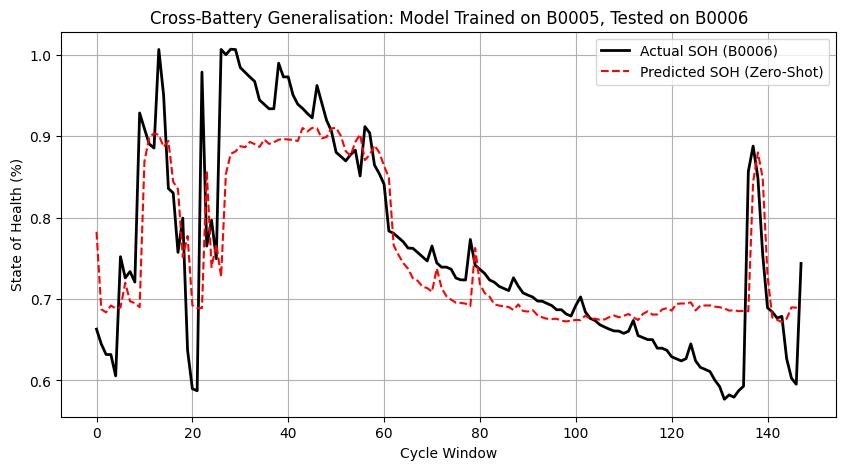

In [ ]:
# --- Phase 9: Cross-Battery Generalisation Test ---

# 1. Extract B0006
X_raw_06, y_raw_06 = extract_and_format_battery(
    base_path=DATASET_PATH,
    battery_id='B0006',
    nominal_capacity=2.0,
    uniform_steps=200
)

print(f"B0006 Extracted: {X_raw_06.shape[0]} cycles")

# 2. Normalise using the PREVIOUSLY FITTED scaler
# DO NOT call fit_transform here. Only transform.
num_cycles_06, steps_06, features_06 = X_raw_06.shape
X_flat_06 = X_raw_06.reshape(-1, features_06)

X_scaled_flat_06 = scaler.transform(X_flat_06) # Using the scaler from B0005
X_scaled_06 = X_scaled_flat_06.reshape(num_cycles_06, steps_06, features_06)

# 3. Create Sequence Windows
dataset_06 = WindowedBatteryDataset(X_scaled_06, y_raw_06, window_size=window_size)
loader_06 = DataLoader(dataset_06, batch_size=16, shuffle=False)

# 4. Evaluate without retraining
actual_soh_06, predicted_soh_06 = test_model('best_battery_model.pth', loader_06, device)

# Optional: Visualise the drift
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(actual_soh_06, label='Actual SOH (B0006)', color='black', linewidth=2)
plt.plot(predicted_soh_06, label='Predicted SOH (Zero-Shot)', color='red', linestyle='dashed')
plt.title('Cross-Battery Generalisation: Model Trained on B0005, Tested on B0006')
plt.xlabel('Cycle Window')
plt.ylabel('State of Health (%)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.onnx

# 1. Load the trained FP32 model
device = torch.device("cpu") # Exporting is best done on CPU
model = CNN_LSTM_BatteryModel().to(device)
model.load_state_dict(torch.load('best_battery_model.pth', map_location=device))
model.eval()

# 2. Dynamic Quantisation (PyTorch Native)
# This converts the heavy nn.LSTM and nn.Linear layers from FP32 to INT8.
# The CNN layers are left alone here because Vitis AI handles spatial quantisation better via its own compiler.
quantized_model = torch.quantization.quantize_dynamic(
    model,
    {nn.LSTM, nn.Linear},
    dtype=torch.qint8
)

# 3. Create a dummy input tensor matching your sequence window
# Shape: (Batch_Size, Window_Size, Time_Steps, Channels)
# We use a batch size of 1 for edge inference.
dummy_input = torch.randn(1, 20, 200, 3, device=device)

# 4. Export to ONNX
onnx_file_path = "battery_soh_edge.onnx"

torch.onnx.export(
    model,                       # Use the base model for standard Vitis AI flow
    dummy_input,
    onnx_file_path,
    export_params=True,          # Store the trained parameter weights inside the model file
    opset_version=13,            # Opset 13 supports most modern RNN/CNN ops
    do_constant_folding=True,    # Optimise the graph by folding constant nodes
    input_names=['sensor_window'],
    output_names=['soh_prediction'],
    dynamic_axes={
        'sensor_window': {0: 'batch_size'}, # Allow variable batch sizing if needed later
        'soh_prediction': {0: 'batch_size'}
    }
)

print(f"Model successfully exported to {onnx_file_path}")

/tmp/ipykernel_13316/2045953504.py:14: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


ModuleNotFoundError: No module named 'onnxscript'